### Dependencias

In [6]:
%pip install opencv-python imutils numpy


DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python3.9 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import cv2
import numpy as np

#### TAREFA 1 – RASTREAMENTO E REVISÃO


In [8]:
# Definir limites de cor para vermelho e verde (HSV)
lower_red = np.array([0, 120, 70])
upper_red = np.array([10, 255, 255])
lower_green = np.array([40, 70, 70])
upper_green = np.array([80, 255, 255])

# Captura da webcam
cap = cv2.VideoCapture(0)

atividade = 1

print(f"Atividade {atividade}: Pressione 'q' para sair.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    h, w, _ = frame.shape
    quadrantes = [
        ((0, 0), (w//2, h//2)),       # Q1
        ((w//2, 0), (w, h//2)),       # Q2
        ((0, h//2), (w//2, h)),       # Q3
        ((w//2, h//2), (w, h))        # Q4
    ]

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    mask_red = cv2.inRange(hsv, lower_red, upper_red)
    mask_green = cv2.inRange(hsv, lower_green, upper_green)

    contours_red, _ = cv2.findContours(mask_red, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours_green, _ = cv2.findContours(mask_green, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    centro_red = centro_green = None

    if contours_red:
        c = max(contours_red, key=cv2.contourArea)
        (x, y, w_r, h_r) = cv2.boundingRect(c)
        centro_red = (x + w_r//2, y + h_r//2)
        cv2.circle(frame, centro_red, 5, (0, 0, 255), -1)

    if contours_green:
        c = max(contours_green, key=cv2.contourArea)
        (x, y, w_g, h_g) = cv2.boundingRect(c)
        centro_green = (x + w_g//2, y + h_g//2)
        cv2.circle(frame, centro_green, 5, (0, 255, 0), -1)

    for idx, ((x1, y1), (x2, y2)) in enumerate(quadrantes, start=1):
        q_img = frame[y1:y2, x1:x2]
        contains_red = centro_red and (x1 <= centro_red[0] < x2 and y1 <= centro_red[1] < y2)
        contains_green = centro_green and (x1 <= centro_green[0] < x2 and y1 <= centro_green[1] < y2)

        if contains_red and contains_green:
            lap = cv2.Laplacian(q_img, cv2.CV_64F)
            lap = cv2.convertScaleAbs(lap)
            blur = cv2.GaussianBlur(q_img, (7, 7), 0)
            result = cv2.addWeighted(lap, 0.5, blur, 0.5, 0)
        elif contains_red:
            result = cv2.Laplacian(q_img, cv2.CV_64F)
            result = cv2.convertScaleAbs(result)
        elif contains_green:
            result = cv2.GaussianBlur(q_img, (7, 7), 0)
        else:
            if idx == 1:
                result = q_img.copy()
                result[:] = (0, 255, 0)
                result = cv2.addWeighted(q_img, 0.5, result, 0.5, 0)
            elif idx == 2:
                gray = cv2.cvtColor(q_img, cv2.COLOR_BGR2GRAY)
                _, binarizada = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
                kernel = np.ones((5, 5), np.uint8)
                result = cv2.morphologyEx(binarizada, cv2.MORPH_CLOSE, kernel)
                result = cv2.cvtColor(result, cv2.COLOR_GRAY2BGR)
            elif idx == 3:
                ycrcb = cv2.cvtColor(q_img, cv2.COLOR_BGR2YCrCb)
                lower_skin = np.array([0, 133, 77], dtype=np.uint8)
                upper_skin = np.array([255, 173, 127], dtype=np.uint8)
                mask = cv2.inRange(ycrcb, lower_skin, upper_skin)
                result = cv2.bitwise_and(q_img, q_img, mask=mask)
            elif idx == 4:
                gray = cv2.cvtColor(q_img, cv2.COLOR_BGR2GRAY)
                kernel = np.ones((3, 3), np.uint8)
                eroded = cv2.erode(gray, kernel, iterations=1)
                result = cv2.cvtColor(eroded, cv2.COLOR_GRAY2BGR)
        frame[y1:y2, x1:x2] = result

    cv2.imshow("Atividade 1 - Rastreamento e Filtros", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Atividade 1: Pressione 'q' para sair.


KeyboardInterrupt: 

: 

#### Resultado

Resultado final da Atividade 6:


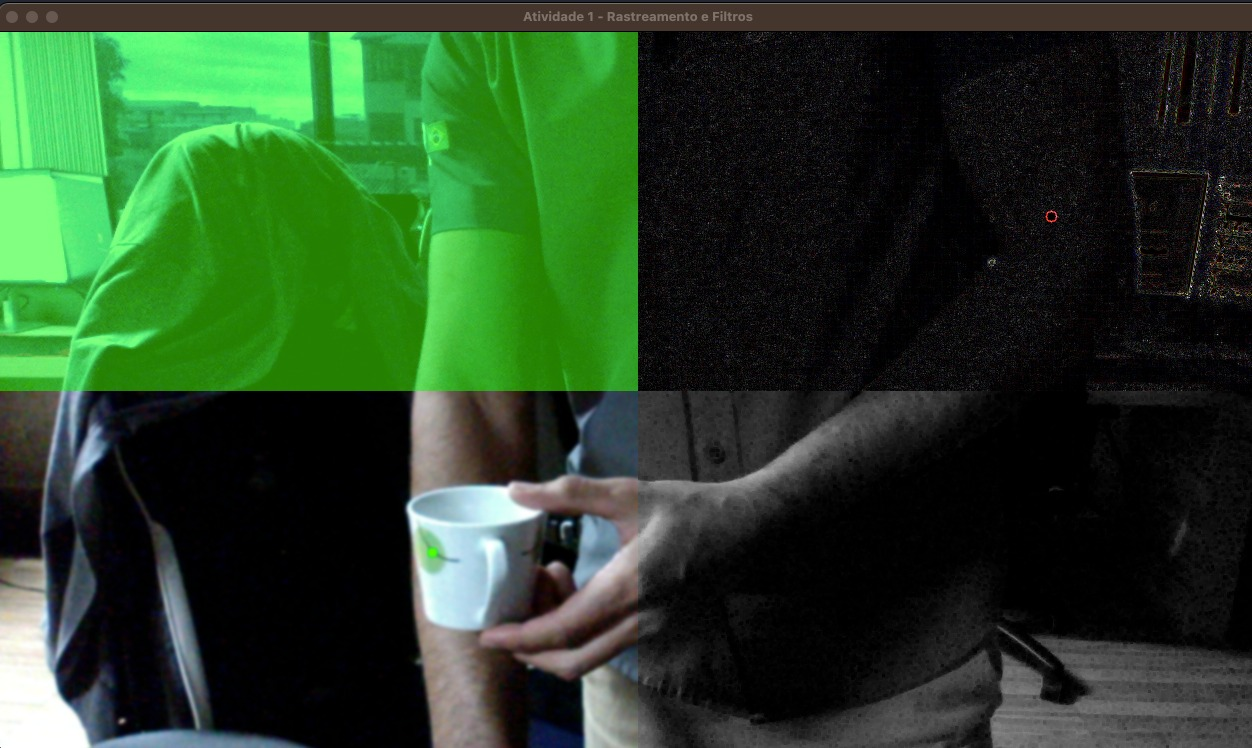

In [9]:
from IPython.display import Image, display

print("Resultado final da Atividade 6:")
display(Image(filename="output.jpeg"))
